# Hands-on #4: PyMC3

In [1]:
import numpy as np
import pymc3 as pm
import arviz as az
import pandas as pd

In [2]:
durations = np.random.exponential(scale=10.0, size=1000)

In [3]:
durations

array([2.22866108e+00, 3.86305058e+01, 7.49067714e+00, 1.09994268e+01,
       3.72291505e+00, 4.03404351e+00, 7.16538571e+00, 5.57003781e+00,
       6.57592755e+00, 1.35529074e+00, 1.37766492e+01, 2.65211255e+00,
       7.18284481e+00, 1.36623431e+01, 4.54225988e+00, 1.13375420e+01,
       2.85588917e+00, 3.09739786e+01, 2.25799175e+00, 3.80509742e-01,
       9.81834419e+00, 1.28008493e+01, 1.30445695e+01, 2.88641370e+00,
       1.20109019e+00, 3.28712590e-01, 3.89074337e+01, 9.85219578e+00,
       7.38468653e+00, 1.41144850e+01, 4.59733759e+00, 2.77473488e+01,
       8.44244866e-01, 2.59570755e+00, 5.21473302e+00, 1.73312203e+01,
       8.17544450e+00, 4.54593030e+00, 1.67511604e+01, 1.07243974e+01,
       1.65403026e+00, 5.74229594e-01, 5.98155039e+00, 3.47685338e+00,
       4.65305240e+00, 2.59048277e+00, 3.74290952e+00, 2.87167198e+00,
       2.65531563e+01, 1.31688660e+00, 1.18445900e+00, 1.07958087e+01,
       1.80381445e+01, 3.72863011e+01, 8.28933129e+00, 7.26150815e+00,
      

In [4]:
s = pd.Series(durations)
s.describe()

count    1000.000000
mean        9.588762
std        10.254399
min         0.011672
25%         2.655617
50%         6.162868
75%        13.378171
max        94.559301
dtype: float64

In [5]:
model = pm.Model()

with model:
    # This part was left empty
    scale = pm.Uniform('scale', lower=0, upper=100)
    lp = pm.Exponential('lp', lam=1/scale, observed=durations)
    trace = pm.sample(5000, chains=2, random_seed=123)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_64566/859551602.py:7: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=2, random_seed=123)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [scale]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 6 seconds.


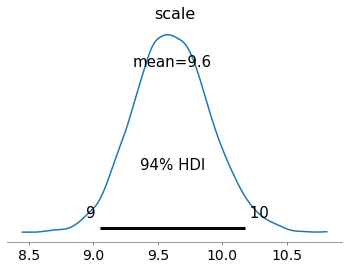

In [6]:
with model:
    az.plot_posterior(trace)  # TODO. plot the posterior function

In [7]:
az.summary(trace, hdi_prob=0.95) # TODO Get the summary statistics

Got error No model on context stack. trying to find log_likelihood in translation.
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
scale,9.608,0.301,9.046,10.219,0.005,0.003,4029.0,6865.0,1.0
